# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train-2.csv')

In [4]:
raw_df[:5]

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [6]:
raw_df.isna().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


отже, у нас є одне пропущене значення в колонці text, та одне в selected_text

In [7]:
raw_df = raw_df.dropna()

In [8]:
raw_df.isna().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [9]:
raw_df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


У нас три класт і досить збалансований розподіл класів але все ж нейтральних прикладів трохи більше

In [10]:
df_copy = raw_df.copy()

In [11]:
df_copy['text_len'] = df_copy['text'].str.len()

In [12]:
df_copy['text_len'][:5]

,text_len
0,36
1,46
2,25
3,31
4,75


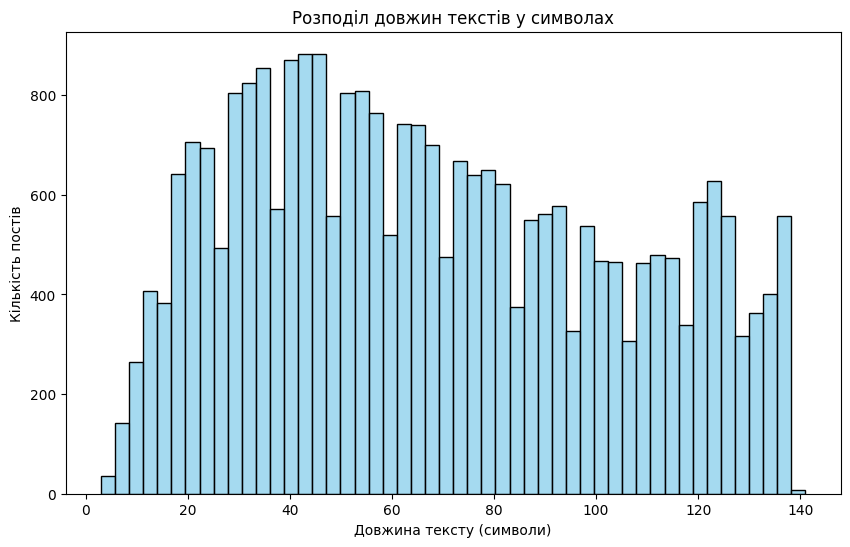

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_copy['text_len'], bins=50, kde=False, color="skyblue")
plt.title("Розподіл довжин текстів у символах")
plt.xlabel("Довжина тексту (символи)")
plt.ylabel("Кількість постів")
plt.show()


найбільше постів короткі (20–60 символів).
Є «довгий хвіст» і рідкісні дуже довгі тексти.



In [14]:
df_copy.groupby('sentiment')['text_len'].describe()


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,7781.0,70.488112,35.155991,5.0,42.0,66.0,98.0,141.0
neutral,11117.0,65.206800,36.407550,3.0,35.0,59.0,94.0,141.0
positive,8582.0,70.419133,34.647770,5.0,42.0,67.0,98.0,138.0


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [15]:
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

stemmer = SnowballStemmer("english")

def stem_text(text):
    return " ".join(stemmer.stem(w) for w in text.split())

raw_df['text_stemmed'] = raw_df['text'].apply(stem_text)

vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(raw_df['text_stemmed'])

print(vectorizer.get_feature_names_out()[:30])
print(X.shape)


['10' '100' '11' '12' '13' '14' '15' '1st' '20' '24' '25' '2day' '2nd'
 '30' '40' '45' '4th' '50' 'abl' 'absolut' 'access' 'account' 'act'
 'actual' 'actually' 'ad' 'add' 'afraid' 'afternoon' 'age']
(27480, 1000)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
y = raw_df['sentiment']
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train_bow.shape)
print("Test shape:", X_test_bow.shape)

Train shape: (19236, 1000)
Test shape: (8244, 1000)


In [18]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_bow, y_train)
y_pred_log = log_reg.predict(X_test_bow)

print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

    negative       0.70      0.58      0.63      2334
     neutral       0.62      0.74      0.67      3335
    positive       0.77      0.69      0.73      2575

    accuracy                           0.68      8244
   macro avg       0.70      0.67      0.68      8244
weighted avg       0.69      0.68      0.68      8244

[[1350  838  146]
 [ 466 2472  397]
 [ 105  692 1778]]


In [19]:
tree = DecisionTreeClassifier(max_depth=20, random_state=42)
tree.fit(X_train_bow, y_train)
y_pred_tree = tree.predict(X_test_bow)

print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

              precision    recall  f1-score   support

    negative       0.76      0.29      0.42      2334
     neutral       0.52      0.87      0.65      3335
    positive       0.77      0.54      0.64      2575

    accuracy                           0.60      8244
   macro avg       0.69      0.57      0.57      8244
weighted avg       0.67      0.60      0.58      8244

[[ 677 1530  127]
 [ 161 2894  280]
 [  51 1125 1399]]


In [20]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_bow, y_train)
y_pred_gb = gb.predict(X_test_bow)

print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

              precision    recall  f1-score   support

    negative       0.77      0.42      0.54      2334
     neutral       0.56      0.83      0.67      3335
    positive       0.78      0.61      0.68      2575

    accuracy                           0.65      8244
   macro avg       0.70      0.62      0.63      8244
weighted avg       0.69      0.65      0.64      8244

[[ 984 1212  138]
 [ 239 2779  317]
 [  58  939 1578]]


Найкраща модель це Logistic Regression (accuracy 0.68, збалансованіші метрики).
Decision Tree переобучається і занадто передбачає клас neutral.
Gradient Boosting працює краще за дерево, але не перевершує логістичну регресію на цих даних.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [23]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = log_reg.coef_

# для кожного класу подивимось топ-10 слів
for i, class_label in enumerate(log_reg.classes_):
    top10 = np.argsort(coefs[i])[-10:]   # найбільші коефіцієнти
    bottom10 = np.argsort(coefs[i])[:10] # найменші коефіцієнти
    print(f"\nКлас: {class_label}")
    print("Найбільше впливають:", feature_names[top10])
    print("Найменше впливають:", feature_names[bottom10])



Клас: negative
Найбільше впливають: ['unfortun' 'headach' 'fail' 'stupid' 'worst' 'hate' 'sorri' 'bored'
 'suck' 'sad']
Найменше впливають: ['awesome' 'glad' 'love' 'awesom' 'thank' 'hugs' 'excited' 'welcom' 'amaz'
 'cute']

Клас: neutral
Найбільше впливають: ['paid' 'guitar' 'sexi' 'mmm' 'area' 'lesson' 'shame' 'david' 'jus'
 'going']
Найменше впливають: ['wors' 'product' 'proud' 'wtf' 'fantast' 'problem' 'tummi' 'worth'
 'worri' 'law']

Клас: positive
Найбільше впливають: ['amaz' 'amazing' 'excited' 'gorgeous' 'cute' 'glad' 'awesom' 'love'
 'thank' 'awesome']
Найменше впливають: ['sad' 'sorri' 'shame' 'bored' 'suck' 'tired' 'jealous' 'hate' 'sucks'
 'unfortun']


у класі neutral є слова, які не мали потрапити у найбільш впливові - sexi,shame. Очевидно що вони мають емоційне забарвлення.
чому так сталось, як було вище описано у нас є незбалансованість класів а саме у neutral маємо найбільшу кількість постів. Також потрібно провести більш ретельну очистку тексту.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
# X = тексти (стемовані), y = мітки
X = raw_df['text_stemmed']
y = raw_df['sentiment']

# той самий split, що й у BoW
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# TF-IDF векторизація
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

# Класифікатор (той самий, що й у BoW)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_tfidf))
print(confusion_matrix(y_test, y_pred_tfidf))


Train shape: (19236, 1000)
Test shape: (8244, 1000)
              precision    recall  f1-score   support

    negative       0.70      0.57      0.63      2334
     neutral       0.61      0.75      0.67      3335
    positive       0.77      0.68      0.72      2575

    accuracy                           0.68      8244
   macro avg       0.69      0.67      0.67      8244
weighted avg       0.69      0.68      0.68      8244

[[1337  850  147]
 [ 471 2486  378]
 [ 107  719 1749]]


In [25]:
# Отримуємо список токенів
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = clf.coef_

# Для кожного класу виводимо топ-10
for i, class_label in enumerate(clf.classes_):
    # індекси найбільших і найменших коефіцієнтів
    top10 = np.argsort(coefs[i])[-10:]
    bottom10 = np.argsort(coefs[i])[:10]

    print(f"\nКлас: {class_label}")
    print("Найбільше впливають:", feature_names[top10])
    print("Найменше впливають:", feature_names[bottom10])



Клас: negative
Найбільше впливають: ['poor' 'bored' 'fail' 'sick' 'stupid' 'suck' 'miss' 'sorri' 'hate' 'sad']
Найменше впливають: ['love' 'thank' 'glad' 'awesome' 'great' 'hope' 'awesom' 'nice' 'enjoy'
 'cute']

Клас: neutral
Найбільше впливають: ['gd' 'airport' 'area' 'lesson' 'mmm' 'differ' 'updat' 'guitar' 'going'
 'goin']
Найменше впливають: ['happi' 'good' 'worri' 'nice' 'stupid' 'wors' 'amazing' 'fail' 'problem'
 'thank']

Клас: positive
Найбільше впливають: ['glad' 'awesom' 'hope' 'good' 'awesome' 'nice' 'great' 'happi' 'thank'
 'love']
Найменше впливають: ['sad' 'sorri' 'miss' 'hate' 'suck' 'sick' 'tired' 'tire' 'shame' 'bored']


У TF‑IDF топові токени виглядають значно логічніше: позитивні слова для positive, негативні для negative, а для neutral — більш «сухі» слова без емоційного забарвлення.

F1‑score по класах виглядає більш збалансованим ніж у BoW

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [26]:
y_pred = clf.predict(X_test_tfidf)

# індекси помилкових передбачень
errors_idx = (y_pred != y_test)

# приклади помилок
errors_df = pd.DataFrame({
    "text": X_test_text[errors_idx],
    "true": y_test[errors_idx],
    "pred": y_pred[errors_idx]
})

print(errors_df.sample(10, random_state=42))


                                                    text      true      pred
23045  big laptop is too big, so it` time to switch t...  positive   neutral
8948   i haven`t been repli to peopl becaus seriously...   neutral  negative
12365                   i nvr want may to come to an end  positive   neutral
3217   no prob, skittl we alway gonna have yall` back...  negative   neutral
24154  #bgt quit an awkward moment, poor girl i hope ...   neutral  negative
15919         o **** i just accident listen to rick ross  negative   neutral
20002  nooo i wanna watch the comet dont wanna go wor...  negative   neutral
9024                            lovin` my new blackberri  positive   neutral
4215   it` official- the twilight saga has ended...*s...   neutral  negative
22555              waaaa. i ran my machin problem! yeah!   neutral  negative


Короткі тексти або з неявною емоцією часто плутаються.
Сарказм/іронія (наприклад - nooo i wanna) модель не розпізнає.
Рідкісні слова/форми (lovin’ замість love) не завжди враховуються.
Слова з подвійним значенням (problem, end) можуть тягнути у негатив, навіть якщо контекст нейтральний.

Способи поліпшення якості
1. Покращення векторизації
Збільшити словник, щоб враховувати більше варіантів слів.
Використати лематизацію замість стемінгу, щоб уникнути втрати смислу

2. Балансування та очищення даних
Відсікати рідкісні слова , щоб уникати шуму.
Додати кастомний список стоп-слів
Перевірити баланс класів і використати class_weight='balanced'.

3. Спробувати інші моделі

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model